In [3]:
import rastereasy

With `rastereasy`, you can plot spectral bands associated with selected pixels by a simple click. You can also extract in a list of numpy arrays the associated values.

# Important for google colab

To use the interactive plotting features in Google Colab, a special two-step setup is required. Follow these steps in the exact order. Separating the commands into different cells and restarting the session is **essential**.

### Step 1: Install Libraries

Run the following cell to install `rastereasy` and the necessary dependencies for interactive widgets.

```
!pip install rastereasy ipympl
from google.colab import output
output.enable_custom_widget_manager()
```

### Step 2: Restart the Runtime

After the installation is complete, you **must** restart the runtime.

Go to the menu: ``Runtime > Restart runtime`` (or use the shortcut `Ctrl+M`).

### Step 3: Run Your Code

After restarting, you can now enable the interactive mode and use the library in a **new cell**.

```
%matplotlib widget
import rastereasy
```


# 1) Open an image

In [4]:
name_im='./data/demo/sentinel.tif'
names = {"NIR":8,"G":3,"CO" : 1,"SWIR2":11,"B": 2,"R":4,"RE1":5,"RE2":6,"RE3":7,"WA":9,"SWIR1":10,"SWIR3":12}
image_names=rastereasy.Geoimage(name_im,names=names)

# 2) Plot spectra by clicking on pixels

In [5]:
help(image_names.plot_spectra)

Help on method plot_spectra in module rastereasy.rastereasy:

plot_spectra(bands=None, fig_size=(15, 5), percentile=2, title='', title_im='Original image (click outside to stop)', title_spectra='Spectra', xlabel='Bands', ylabel='Value', zoom=None, pixel=None) method of rastereasy.rastereasy.Geoimage instance
    Interactive tool to explore and plot spectral values from user-selected pixels.
    
    This method displays the image and allows the user to click on pixels to see
    their spectral values across all bands plotted as a line graph. Multiple pixels
    can be selected to compare different spectral signatures.
    
    Parameters
    ----------
    bands : list of str, optional
        List of three band identifiers to use for the background image display.
        If None, uses the first three bands in the image.
        Default is None.
    
    fig_size : tuple, optional
        Size of the figure in inches as (width, height).
        Default is (15, 5).
    
    percentile :

## Plot spectra with the three first bands in color composition


You can click on the `Finish` button or outside the image to stop the visualization.

nootebook


Label(value='Click on the image to retrieve spectra.')

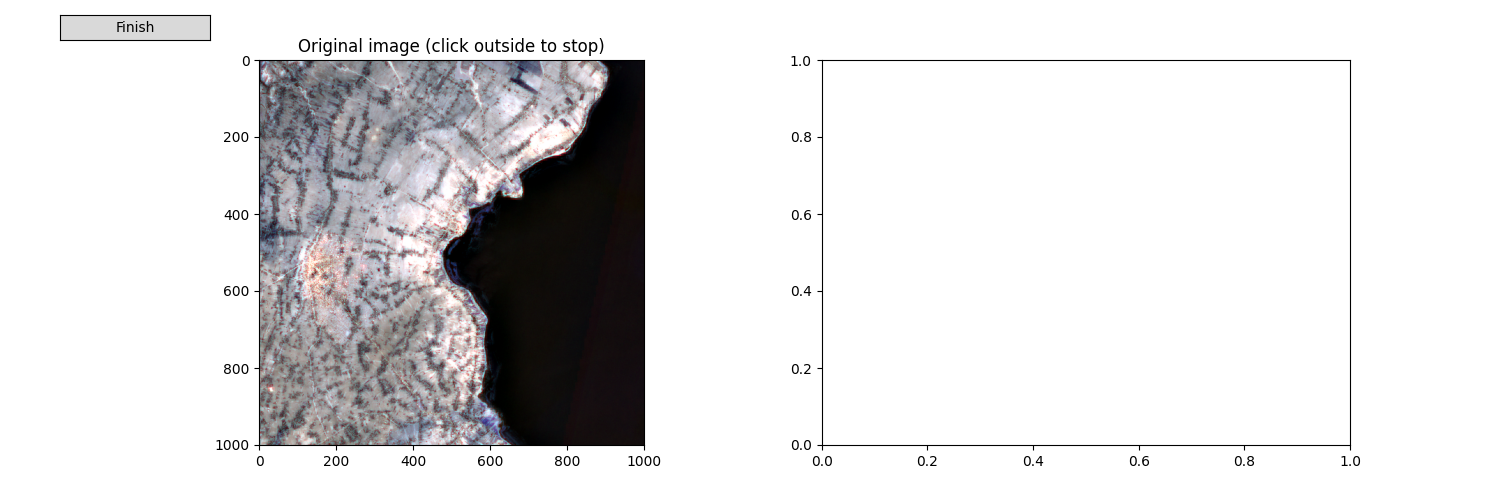

([], [], [])

In [7]:
# If google colab, do not forget to put `%matplotlib widget` before importing rastereasy
image_names.plot_spectra()
#image_names_crop.colorcomp(extent='pixel')
# -> This will plot an image where you can click to visualize spectre

## Plot spectra with selected bands for color composition


nootebook


Label(value='Click on the image to retrieve spectra.')

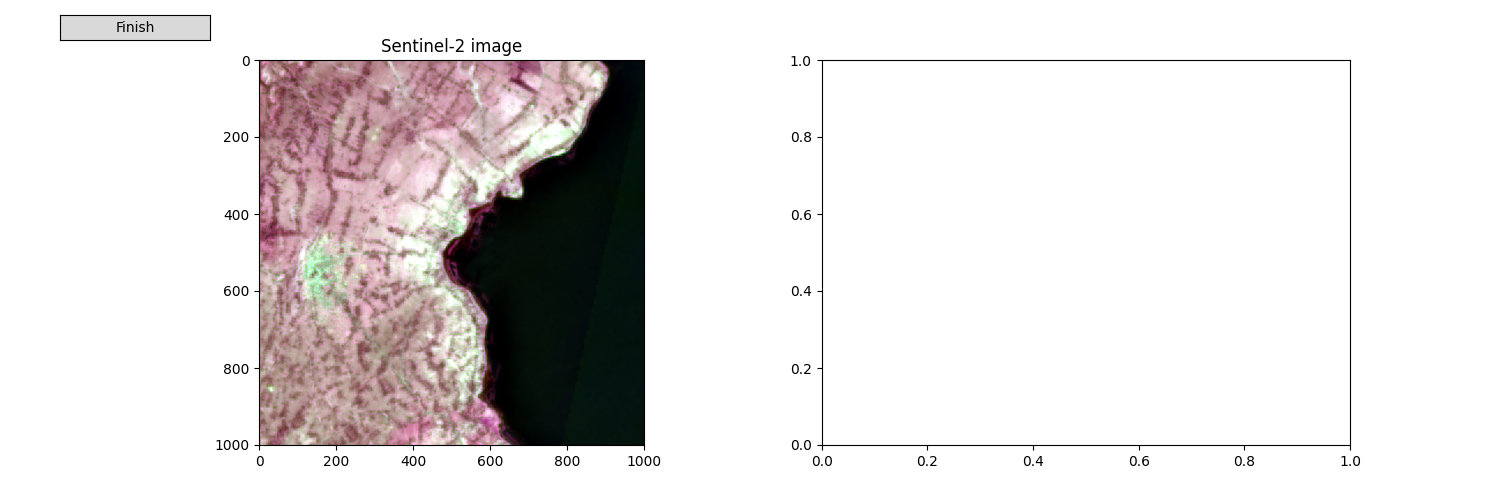

([], [], [])

In [8]:
image=rastereasy.Geoimage(name_im)
# If google colab, do not forget to put `%matplotlib widget` before importing rastereasy
image.plot_spectra(['5','1','3'],title_im='Sentinel-2 image',title_spectra='associated spectra',xlabel='given bands',ylabel='spectral values')

# -> This will plot an image where you can click to visualize spectre


# 3) Get spectral values of some pixels selected by a simple click

To this end, you need to put in some variables the outputs

nootebook


Label(value='Click on the image to retrieve spectra.')

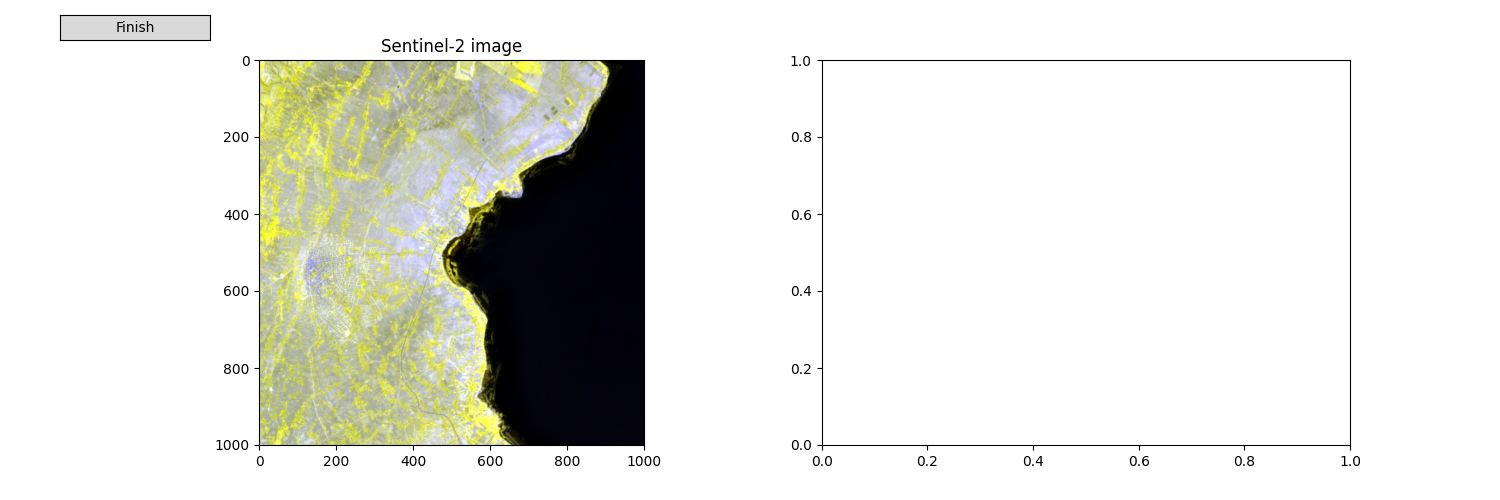

In [9]:
# If google colab, do not forget to put `%matplotlib widget` before importing rastereasy
series, pixels_i,pixels_j = image.plot_spectra(['8','9','2'],title_im='Sentinel-2 image',title_spectra='associated spectra',xlabel='given bands',ylabel='spectral values')


In [10]:
print('collect %d spectra'%len(series))
for i in range(len(series)):
    print('*[%.3d] pixel i = '%(i+1), pixels_i[i], 'pixel j = ', pixels_j[i], 'spectral values = ',series[i])

collect 12 spectra
*[001] pixel i =  483 pixel j =  502 spectral values =  [ 282  385  700  583 1121 1787 1731 1807 1896 2054  996  627]
*[002] pixel i =  473 pixel j =  606 spectral values =  [236 283 482 342 357 216 232 221 220 197 206 170]
*[003] pixel i =  252 pixel j =  494 spectral values =  [ 821  804 1030 1438 2061 2304 2489 2344 2686 2690 3378 3015]
*[004] pixel i =  392 pixel j =  354 spectral values =  [ 923 1160 1500 2040 2204 2348 2492 2432 2655 2628 3319 3122]
*[005] pixel i =  564 pixel j =  417 spectral values =  [1109 1114 1378 1768 2259 2404 2536 2452 2709 2697 3487 3318]
*[006] pixel i =  551 pixel j =  684 spectral values =  [248 260 490 334 355 245 258 231 238 221 173 132]
*[007] pixel i =  442 pixel j =  718 spectral values =  [244 282 497 343 347 242 237 224 228 215 175 141]
*[008] pixel i =  366 pixel j =  746 spectral values =  [221 259 447 321 342 217 224 216 213 190 181 147]
*[009] pixel i =  211 pixel j =  489 spectral values =  [ 912 1128 1464 1946 2122 231

nootebook


Label(value='Click on the image to retrieve spectra.')

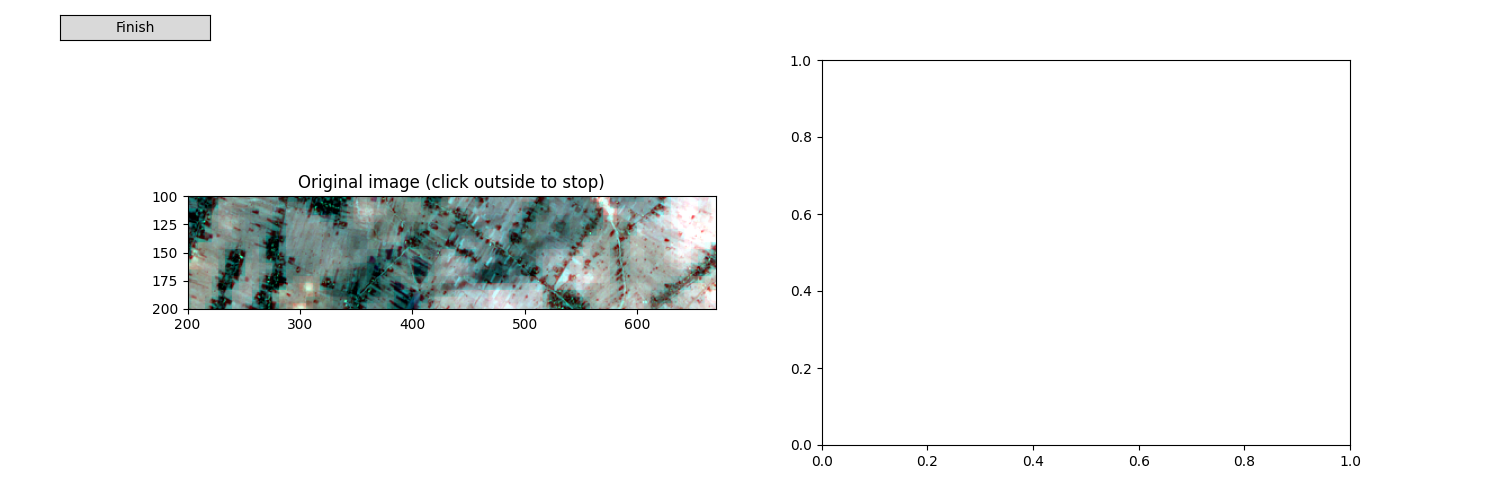

In [11]:
# 4) Get spectral values of some pixels by zooming the image

series, pixels_i,pixels_j = image_names.plot_spectra(zoom=((100,200),(200,670)))
#series, pixels_i,pixels_j = image_names.plot_spectra()


In [12]:
print('collect %d spectra'%len(series))
for i in range(len(series)):
    print('*[%.3d] pixel i = '%(i+1), pixels_i[i], 'pixel j = ', pixels_j[i], 'spectral values = ',series[i])

collect 7 spectra
*[001] pixel i =  157 pixel j =  310 spectral values =  [ 746  946 1262 1704 1914 2035 2154 2133 2281 2295 3125 3068]
*[002] pixel i =  150 pixel j =  367 spectral values =  [ 689  960 1288 1688 1933 2136 2296 2257 2520 2470 3227 3027]
*[003] pixel i =  154 pixel j =  415 spectral values =  [ 709  773 1084 1372 1825 2070 2252 2416 2514 2483 3315 3052]
*[004] pixel i =  154 pixel j =  455 spectral values =  [ 708  800 1094 1482 1918 2183 2359 2462 2559 2442 3137 2882]
*[005] pixel i =  133 pixel j =  496 spectral values =  [ 617  730 1028 1466 1752 1948 2124 2024 2292 2478 3082 2898]
*[006] pixel i =  152 pixel j =  534 spectral values =  [ 816 1152 1534 2014 2247 2384 2452 2454 2551 2474 3458 3406]
*[007] pixel i =  164 pixel j =  526 spectral values =  [ 859  855 1174 1588 1910 2196 2372 2396 2615 2661 3345 3149]
